# 1. Data Understanding

## 1.1 load dataset

In [156]:
import pandas as pd

df = pd.read_csv('datasets/student_dataset_10000_rows.csv')
df.head()


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 690.1 KB


In [158]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [159]:
df.isna().sum(
)

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [160]:
df.duplicated().sum()

np.int64(0)

### disini tidak perlu data cleaning lagi dikarenakan data sudah bersih dari missing value dan duplicate data

## 1.2 cek distribusi data dan data imbalance target variable

In [161]:
df['placement_status'].value_counts()

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

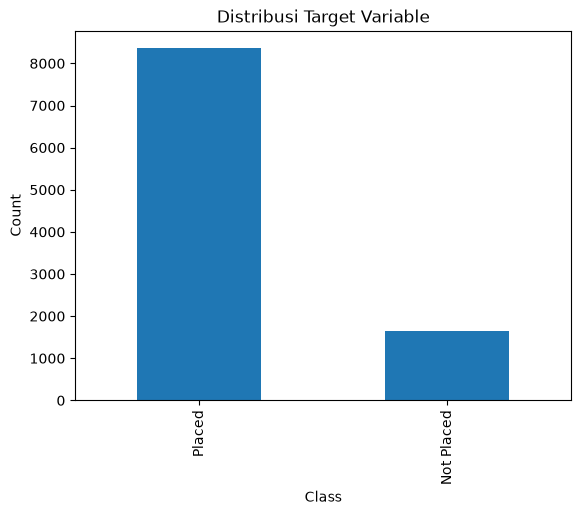

In [162]:
import matplotlib.pyplot as plt

df['placement_status'].value_counts().plot(kind='bar')
plt.title('Distribusi Target Variable')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# 2. Exploratory Data Analysis (EDA)

## 2.1 Visualisasi distribusi tiap fitur 

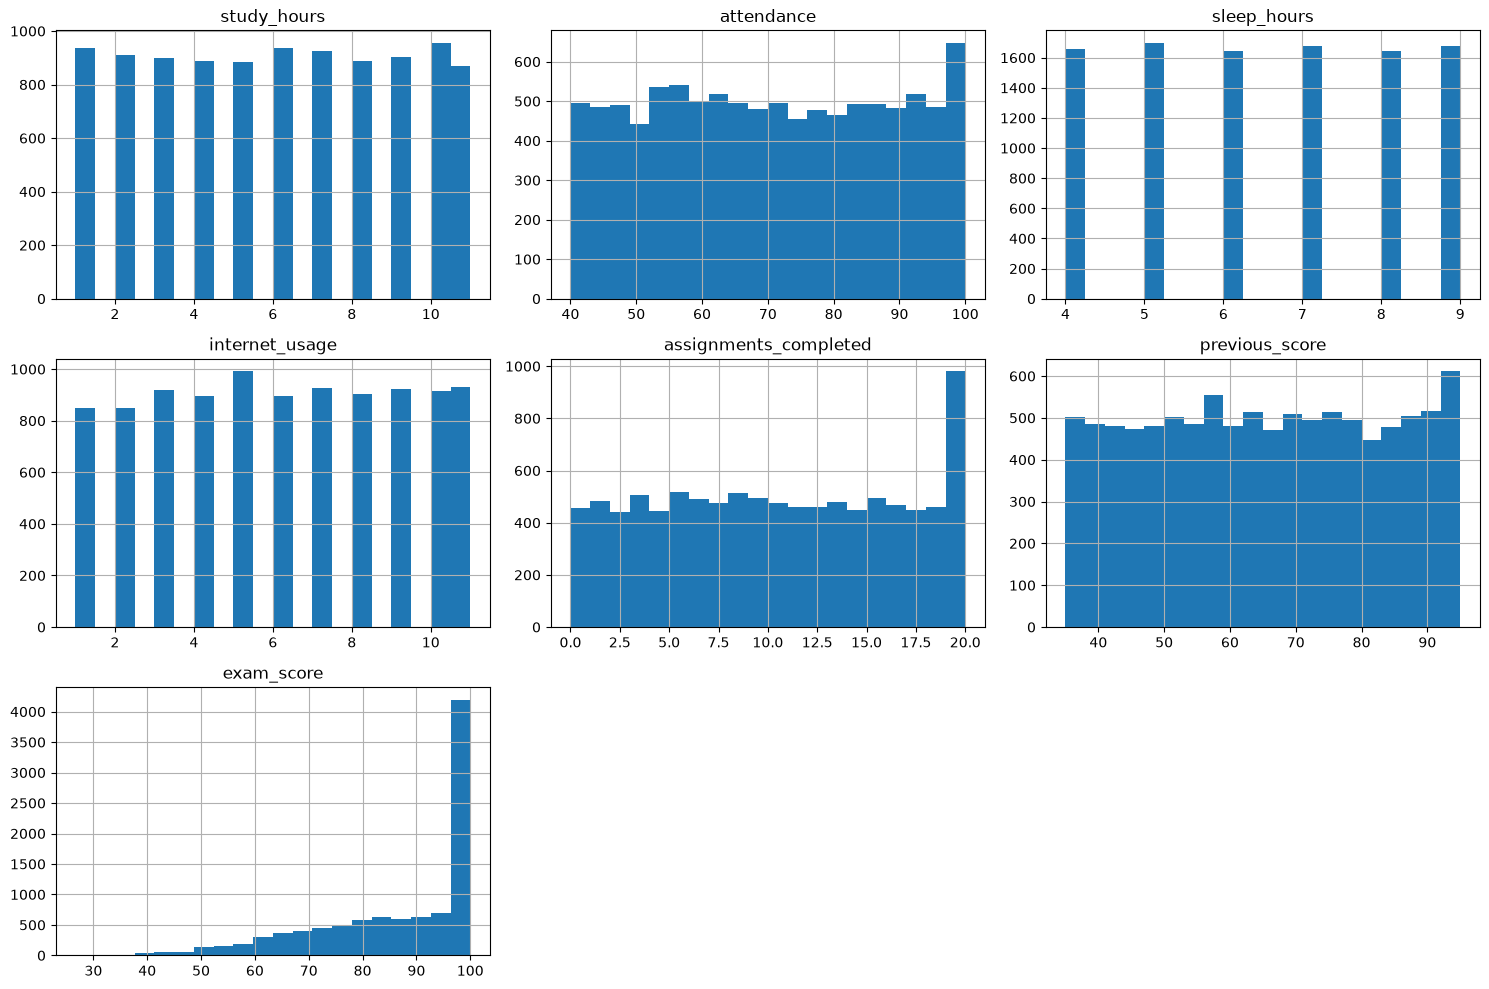

In [163]:
df.select_dtypes(include=['int64', 'float64']).hist(
    figsize=(15,10),
    bins=20,
    layout=(3,3)
)

plt.tight_layout()
plt.show()

## 2.2 Heatmap korelasi antar fitur dan terhadap target

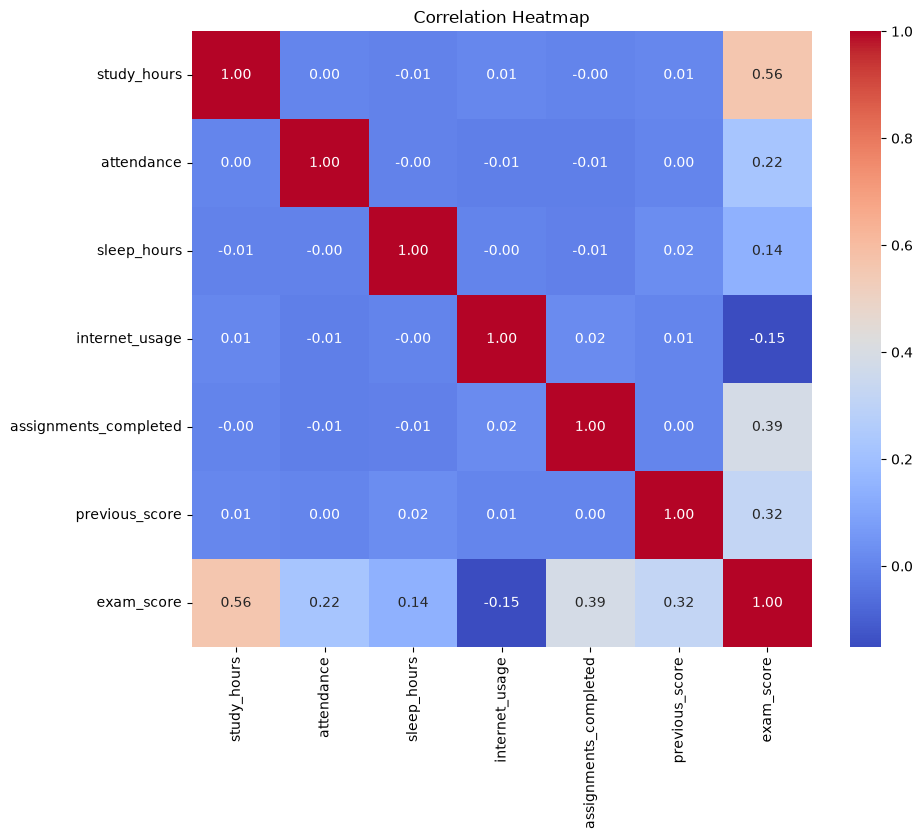

In [164]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

### Berdasarkan heatmap korelasi, tidak ditemukan korelasi yang sangat tinggi antar fitur. Nilai korelasi tertinggi terdapat pada study_hours dan exam_score sebesar 0,56 yang menunjukkan hubungan positif sedang. Hasil ini mengindikasikan bahwa setiap fitur masih memberikan informasi yang berbeda sehingga seluruh fitur dapat digunakan dalam proses pemodelan tanpa risiko multikolinearitas yang signifikan.

## 2.3 Visualisasi perbandingan fitur antar kelas target

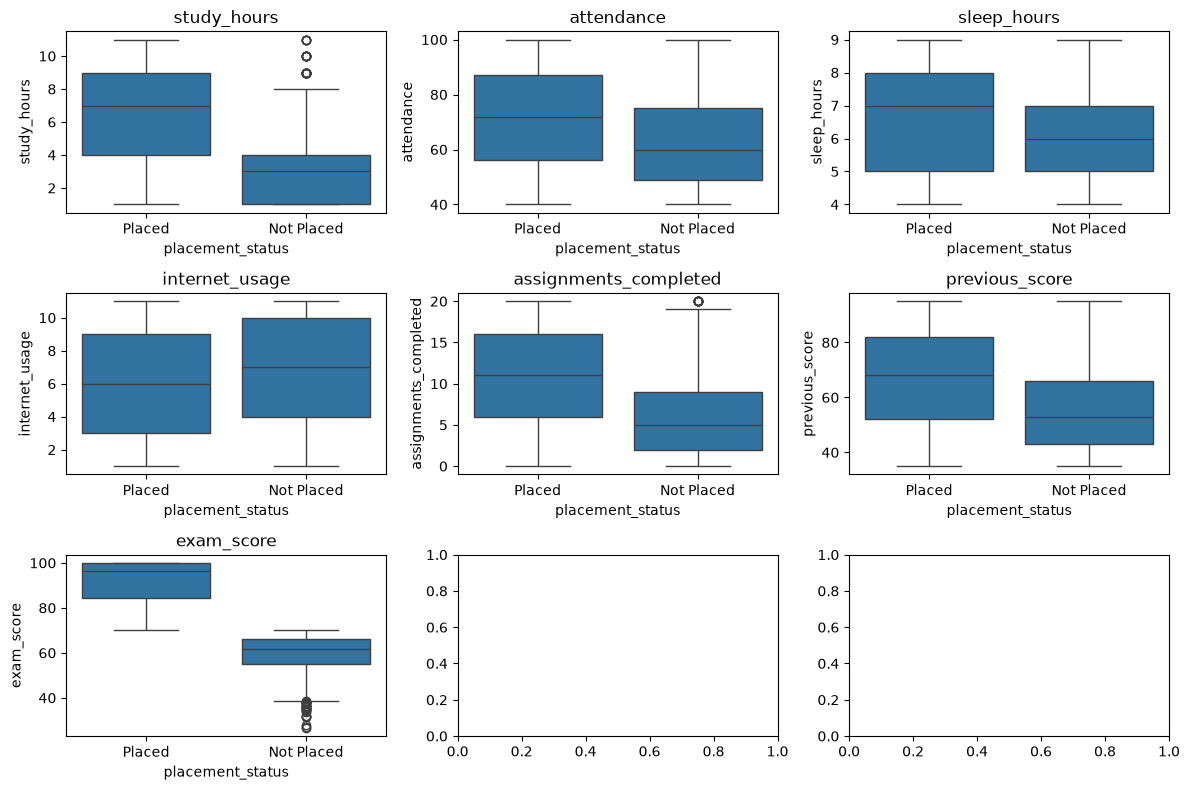

In [165]:
cols = df.select_dtypes(include=['int64','float64']).columns

fig, axes = plt.subplots(3, 3, figsize=(12,8))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.boxplot(data=df, x='placement_status', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Fitur exam_score menunjukkan perbedaan yang sangat signifikan antara kelompok Placed dan Not Placed. Distribusi nilai kedua kelas hampir tidak memiliki tumpang tindih sehingga fitur ini berpotensi memberikan informasi yang terlalu kuat terhadap target. Oleh karena itu fitur ini perlu dievaluasi lebih lanjut untuk menghindari risiko data leakage.

# 3. Deteksi Data Leakage

## 3.1 Cek apakah ada fitur dengan separasi sempurna terhadap target 

In [166]:
df['placement_status'].unique()

<ArrowStringArray>
['Placed', 'Not Placed']
Length: 2, dtype: str

In [167]:
target_col = 'placement_status'

for col in df.select_dtypes(include=['int64', 'float64']).columns:

    min_placed = df[df[target_col] == 'Placed'][col].min()
    max_placed = df[df[target_col] == 'Placed'][col].max()

    min_not = df[df[target_col] == 'Not Placed'][col].min()
    max_not = df[df[target_col] == 'Not Placed'][col].max()

    if min_placed > max_not or min_not > max_placed:
        print(f"{col} -> Perfect Separation")

exam_score -> Perfect Separation


### Fitur "exam_score" dianggap sebagai data leakage karena nilai pada kelas Placed dan Not Placed tidak memiliki tumpang tindih (overlap). Hal ini membuat model dapat mengetahui hasil placement hanya dari fitur tersebut tanpa perlu mempelajari pola lain pada data. Jika fitur ini tetap digunakan, akurasi model bisa menjadi terlalu tinggi dan tidak mencerminkan performa sebenarnya. Oleh karena itu, fitur exam_score dihapus agar model dapat melakukan prediksi secara lebih adil dan realistis.

# 4. Deteksi & handling Outlier 

## 4.1 IQR check per kolom

In [168]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outlier")

study_hours: 0 outlier
attendance: 0 outlier
sleep_hours: 0 outlier
internet_usage: 0 outlier
assignments_completed: 0 outlier
previous_score: 0 outlier
exam_score: 62 outlier


### Terdapat outlier pada kolom exam_score, namun tidak dilakukan penanganan karena kolom tersebut akan dihapus (drop) akibat terindikasi sebagai data leakage yang dapat memengaruhi performa dan validitas model prediksi.

# 5. Feature Engineering & Encoding

## 5.1 membuat fitur turunan baru

In [169]:
# 1. Productive Behavior Score: kombinasi study_hours & assignments_completed
df['productive_score'] = df['study_hours'] * 0.5 + df['assignments_completed'] * 0.3

# 2. Academic Composite: previous_score yang dinormalisasi + attendance
df['academic_composite'] = (df['previous_score'] / 95) * 0.6 + (df['attendance'] / 100) * 0.4

# 3. Digital Distraction: internet_usage berbanding terbalik dengan performa
df['digital_balance'] = df['study_hours'] - df['internet_usage']

# 4. Sleep Quality: sleep_hours dalam range ideal (7-9)
df['sleep_quality'] = df['sleep_hours'].apply(
    lambda x: 1 if 7 <= x <= 9 else (0.5 if x == 6 or x == 10 else 0)
)

df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status,productive_score,academic_composite,digital_balance,sleep_quality
0,7,56,8,7,10,62,100.00,Placed,6.5,0.615579,0,1.0
1,4,69,5,3,8,56,100.00,Placed,4.4,0.629684,1,0.0
2,11,60,7,6,10,45,100.00,Placed,8.5,0.524211,5,1.0
3,8,99,9,8,4,55,90.17,Placed,5.2,0.743368,0,1.0
4,5,52,8,6,8,40,78.82,Placed,4.9,0.460632,-1,1.0


In [170]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['placement_status'] = le.fit_transform(df['placement_status'])

df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status,productive_score,academic_composite,digital_balance,sleep_quality
0,7,56,8,7,10,62,100.00,1,6.5,0.615579,0,1.0
1,4,69,5,3,8,56,100.00,1,4.4,0.629684,1,0.0
2,11,60,7,6,10,45,100.00,1,8.5,0.524211,5,1.0
3,8,99,9,8,4,55,90.17,1,5.2,0.743368,0,1.0
4,5,52,8,6,8,40,78.82,1,4.9,0.460632,-1,1.0


# 6. fitur selection

In [171]:
# Drop fitur yang tidak digunakan
X = df.drop(columns=['placement_status', 'exam_score'])

# Target
y = df['placement_status']

In [172]:
print("Fitur yang digunakan:")
print(X.columns.tolist())

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

Fitur yang digunakan:
['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'productive_score', 'academic_composite', 'digital_balance', 'sleep_quality']

Shape X: (10000, 10)
Shape y: (10000,)


### Pada tahap ini dilakukan pemisahan antara variabel independen (X) dan variabel dependen (y). Variabel target yang digunakan adalah placement_status, sedangkan fitur exam_score dihapus karena terindikasi sebagai data leakage yang dapat menyebabkan model memperoleh informasi yang tidak seharusnya tersedia saat proses prediksi. Dengan demikian, model hanya dilatih menggunakan fitur-fitur yang relevan dan valid.

# 7. Standarization

In [173]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

X_scaled_cluster = scaler_cluster.fit_transform(X)

# 8. K-means Clustering

## 8.1 Elbow Method & Silhouette Score

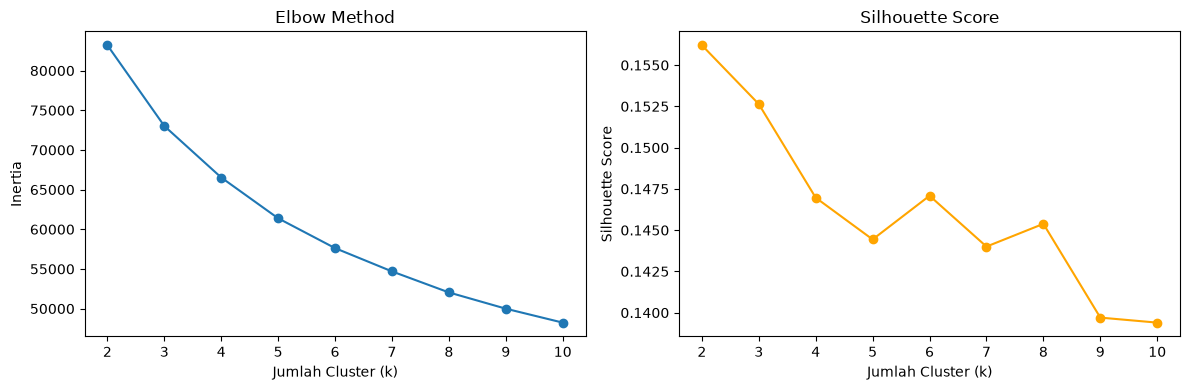

Silhouette Score per k:
k=2: 0.1562
k=3: 0.1526
k=4: 0.1470
k=5: 0.1444
k=6: 0.1471
k=7: 0.1440
k=8: 0.1454
k=9: 0.1397
k=10: 0.1394


In [174]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_cluster)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("Silhouette Score per k:")
for k, score in zip(k_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

## 8.2 Fit K-Means dengan k optimal

In [175]:
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

print(f"Silhouette Score tertinggi: k={best_k} dengan score={best_score:.4f}")
print(f"→ k={best_k} dipilih sebagai jumlah cluster optimal")

optimal_k = best_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_cluster)

df['cluster'] = cluster_labels

print(f"\nJumlah anggota tiap cluster (k={optimal_k}):")
print(df['cluster'].value_counts().sort_index())

Silhouette Score tertinggi: k=2 dengan score=0.1562
→ k=2 dipilih sebagai jumlah cluster optimal

Jumlah anggota tiap cluster (k=2):
cluster
0    4897
1    5103
Name: count, dtype: int64


## 8.3 Profiling: rata-rata fitur per cluster


Profil rata-rata fitur per cluster:
         study_hours  attendance  sleep_hours  internet_usage  \
cluster                                                         
0               3.54       69.27         6.49            6.77   
1               8.34       70.47         6.50            5.38   

         assignments_completed  previous_score  productive_score  \
cluster                                                            
0                         8.35           63.91              4.27   
1                        11.56           65.87              7.64   

         academic_composite  digital_balance  sleep_quality  
cluster                                                      
0                      0.68            -3.23           0.58  
1                      0.70             2.96           0.58  


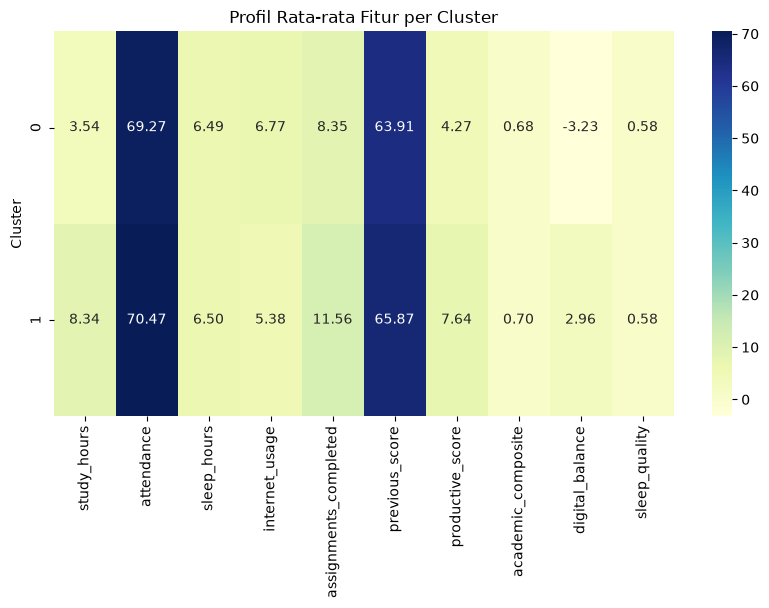

cluster
0    4897
1    5103
Name: count, dtype: int64


In [176]:
profile = df.groupby('cluster')[X.columns].mean().round(2)
print("\nProfil rata-rata fitur per cluster:")
print(profile)

# Heatmap profil cluster
plt.figure(figsize=(10, 5))
sns.heatmap(profile, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Profil Rata-rata Fitur per Cluster')
plt.ylabel('Cluster')
plt.show()

print(df['cluster'].value_counts().sort_index())

In [177]:
cluster_names = {
    0: 'Mahasiswa Kurang Aktif',
    1: 'Mahasiswa Aktif dan Produktif'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

## 8.4 Visualisasi Cluster — PCA 2D

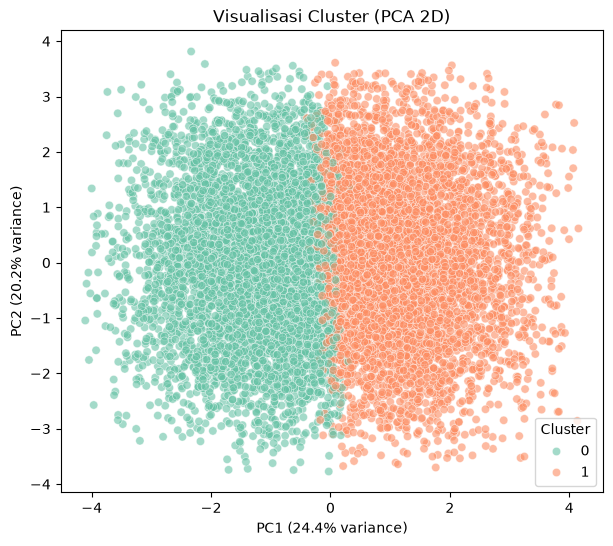

In [178]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_cluster)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=cluster_labels, palette='Set2', alpha=0.6
)
plt.title('Visualisasi Cluster (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.show()


## 8.5 Cross-tab Cluster vs Placement Status


Persentase Placement Status per Cluster:
         Not Placed (%)  Placed (%)
cluster                            
0                 31.88       68.12
1                  1.63       98.37


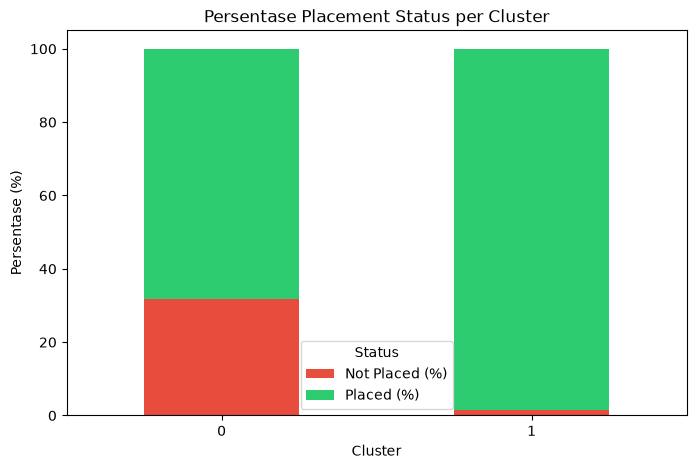

In [179]:
crosstab = pd.crosstab(df['cluster'], df['placement_status'], normalize='index') * 100
crosstab.columns = ['Not Placed (%)', 'Placed (%)']  # sesuai encoding: 0=Not Placed, 1=Placed
print("\nPersentase Placement Status per Cluster:")
print(crosstab.round(2))

crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#e74c3c', '#2ecc71'])
plt.title('Persentase Placement Status per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Persentase (%)')
plt.legend(title='Status')
plt.xticks(rotation=0)
plt.show()

### Clustering berfungsi sebagai analisis deskriptif/profiling.Cluster label TIDAK dimasukkan sebagai fitur ke model Random Forest karena clustering dilakukan pada seluruh dataset (termasuk test set), sehingga akan menyebabkan data leakage jika digunakan sebagai fitur.Insight dari clustering digunakan untuk memahami karakteristik kelompok mahasiswa, bukan sebagai input prediksi.

# 9. Split data 80/20 (train/test)

In [180]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [181]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 10)
X_test : (2000, 10)
y_train: (8000,)
y_test : (2000,)


# 10. Scaling untuk random forest

In [182]:
from sklearn.preprocessing import StandardScaler

scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print("Standardization untuk Random Forest selesai.")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")

Standardization untuk Random Forest selesai.
X_train_scaled: (8000, 10)
X_test_scaled : (2000, 10)


# 11. SMOTE balance data

In [183]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [184]:
print("=== Sebelum SMOTE ===")
print(y_train.value_counts())

print("\n=== Sesudah SMOTE ===")
print(y_train_smote.value_counts())

=== Sebelum SMOTE ===
placement_status
1    6685
0    1315
Name: count, dtype: int64

=== Sesudah SMOTE ===
placement_status
1    6685
0    6685
Name: count, dtype: int64


# 12. Random Forest (prediksi penempatan)

## 12. Hyperparameter tuning

In [185]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_smote, y_train_smote)

best_rf = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)
print(f"\nBest CV F1 Score : {random_search.best_score_:.4f}")



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 25}

Best CV F1 Score : 0.9396


In [186]:
# ===== 12.2 XGBoost - Hyperparameter Tuning =====
from xgboost import XGBClassifier

param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

xgb = XGBClassifier(random_state=42)
rs_xgb = RandomizedSearchCV(xgb, param_dist_xgb, n_iter=50, cv=cv,
                             scoring='f1', n_jobs=-1, verbose=1, random_state=42)
rs_xgb.fit(X_train_smote, y_train_smote)

best_xgb = rs_xgb.best_estimator_
print("Best XGBoost Params:", rs_xgb.best_params_)
print(f"Best XGBoost CV F1: {rs_xgb.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGBoost Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best XGBoost CV F1: 0.9439


## 12.3. Evaluasi Metrics

In [187]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (W)': precision_score(y_test, y_pred, average='weighted'),
        'Recall (W)': recall_score(y_test, y_pred, average='weighted'),
        'F1 (W)': f1_score(y_test, y_pred, average='weighted'),
        'AUC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

results_rf  = evaluate_model('Random Forest', best_rf, X_test_scaled, y_test)
results_xgb = evaluate_model('XGBoost', best_xgb, X_test_scaled, y_test)

comparison_df = pd.DataFrame([
    {k: v for k, v in results_rf.items() if k not in ['y_pred', 'y_prob']},
    {k: v for k, v in results_xgb.items() if k not in ['y_pred', 'y_prob']}
]).set_index('Model').round(4)

print("===== MODEL COMPARISON =====")
print(comparison_df)



===== MODEL COMPARISON =====
               Accuracy  Precision (W)  Recall (W)  F1 (W)     AUC
Model                                                             
Random Forest    0.8870         0.8958      0.8870  0.8905  0.9291
XGBoost          0.8905         0.8898      0.8905  0.8902  0.9248


In [188]:
# ===== 12.4 Pilih Model Terbaik =====
if results_rf['F1 (W)'] >= results_xgb['F1 (W)']:
    best_model = best_rf
    best_model_name = 'Random Forest'
    best_results = results_rf
else:
    best_model = best_xgb
    best_model_name = 'XGBoost'
    best_results = results_xgb

print(f"✓ Model terpilih: {best_model_name}")
print(f"  F1 Score (Weighted): {best_results['F1 (W)']:.4f}")
print(f"  AUC               : {best_results['AUC']:.4f}")

print(f"\n===== CLASSIFICATION REPORT ({best_model_name}) =====")
print(classification_report(
    y_test,
    best_results['y_pred'],
    target_names=['Not Placed', 'Placed']
))


✓ Model terpilih: Random Forest
  F1 Score (Weighted): 0.8905
  AUC               : 0.9291

===== CLASSIFICATION REPORT (Random Forest) =====
              precision    recall  f1-score   support

  Not Placed       0.63      0.74      0.68       329
      Placed       0.95      0.92      0.93      1671

    accuracy                           0.89      2000
   macro avg       0.79      0.83      0.81      2000
weighted avg       0.90      0.89      0.89      2000



In [189]:
from sklearn.model_selection import cross_val_score

cv_check = cross_val_score(
    best_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(f"CV F1 per fold : {cv_check.round(4)}")
print(f"Mean CV F1     : {cv_check.mean():.4f}")
print(f"Std CV F1      : {cv_check.std():.4f}")
print("→ Std tinggi (>0.05) = model tidak stabil antar fold")

CV F1 per fold : [0.899  0.9455 0.9555 0.9438 0.9486]
Mean CV F1     : 0.9385
Std CV F1      : 0.0201
→ Std tinggi (>0.05) = model tidak stabil antar fold


## 12.4 Confusion Matrix

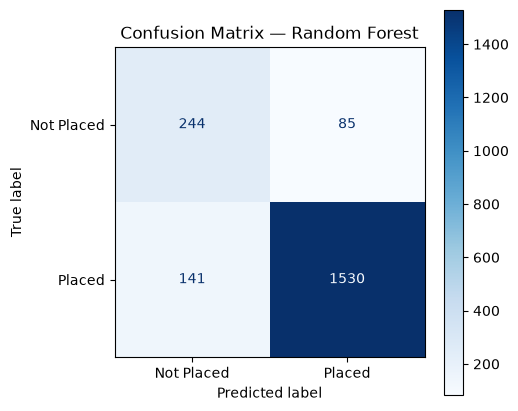

In [190]:
# Confusion Matrix model terbaik
cm = confusion_matrix(y_test, best_results['y_pred'])
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['Not Placed', 'Placed']).plot(cmap='Blues', ax=ax)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

## 12.5 ROC Curve

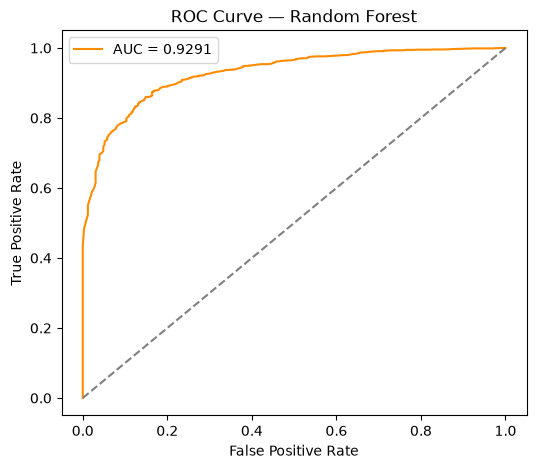

In [191]:
# ROC Curve model terbaik
fpr, tpr, _ = roc_curve(y_test, best_results['y_prob'])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {best_results['AUC']:.4f}", color='darkorange')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_model_name}')
plt.legend()
plt.show()

## 12.6. Feature Importance


===== FEATURE IMPORTANCE =====
productive_score         0.280033
study_hours              0.150051
academic_composite       0.135998
digital_balance          0.117832
assignments_completed    0.083467
previous_score           0.071418
attendance               0.066345
internet_usage           0.040990
sleep_hours              0.038594
sleep_quality            0.015271
dtype: float64


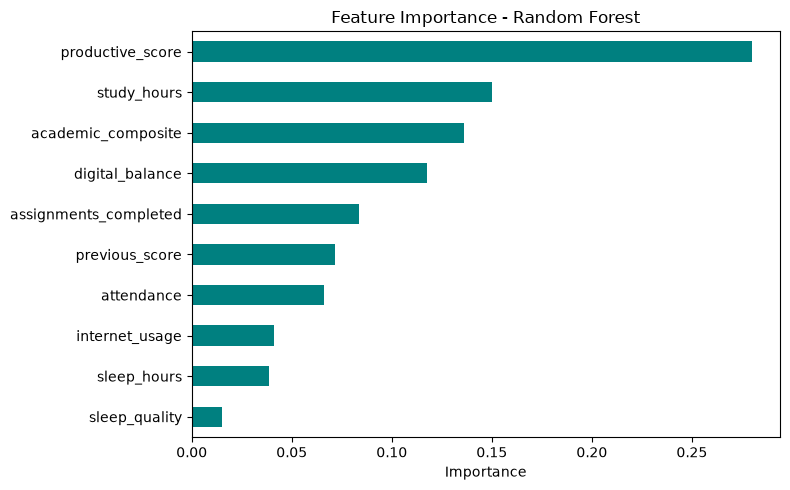

In [ ]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(feature_importance)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh', color='teal')
plt.title(f'Feature Importance - {best_model_name}')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [193]:
# Perbandingan CV Score vs Test Score untuk deteksi overfitting
cv_f1 = random_search.best_score_
test_f1 = best_results['F1 (W)']
gap = abs(cv_f1 - test_f1)

print("\n===== CV vs TEST SCORE COMPARISON =====")
print(f"CV F1 Score (train) : {cv_f1:.4f}")
print(f"Test F1 Score       : {test_f1:.4f}")
print(f"Gap                 : {gap:.4f}")

if gap < 0.03:
    print("✓ Model stabil — tidak ada indikasi overfitting signifikan")
elif gap < 0.07:
    print("⚠ Gap sedang — perlu diwaspadai, pertimbangkan regularisasi lebih kuat")
else:
    print("✗ Gap besar — model kemungkinan overfit pada training data")


===== CV vs TEST SCORE COMPARISON =====
CV F1 Score (train) : 0.9396
Test F1 Score       : 0.8905
Gap                 : 0.0491
⚠ Gap sedang — perlu diwaspadai, pertimbangkan regularisasi lebih kuat


In [194]:
import joblib

joblib.dump(best_model, 'model/best_model.pkl')
joblib.dump(scaler_model, 'model/scaler.pkl')
joblib.dump(X_test, 'model/X_test.pkl')
joblib.dump(y_test, 'model/y_test.pkl')

import json
with open('model/model_info.json', 'w') as f:
    json.dump({'model_name': best_model_name}, f)

print(f"Model '{best_model_name}' berhasil disimpan.")

Model 'Random Forest' berhasil disimpan.


In [195]:
import json

feature_names = X.columns.tolist()
with open('model/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Feature names saved:", feature_names)

Feature names saved: ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'productive_score', 'academic_composite', 'digital_balance', 'sleep_quality']


In [196]:
joblib.dump(le, 'model/label_encoder.pkl')

['model/label_encoder.pkl']

In [197]:
joblib.dump(kmeans, 'model/kmeans.pkl')
joblib.dump(scaler_cluster, 'model/scaler_cluster.pkl')

['model/scaler_cluster.pkl']